# Pre-Processing


### Cleaning and splitting data

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

INPUT_CSV = "vehicles.csv"
TARGET = "comb08"
MISSING_COL_THRESHOLD = 0.60    # drop columns with >60% missing
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Features that "leak" the target or are derived from MPG / fuel burn / cost
LEAKAGE_COLS = [
    # Directly related MPG fields (fuelType1)
    "city08", "highway08", "comb08U", "city08U", "highway08U", "UCity", "UHighway",
    # Directly derived from fuel use / mpg economics
    "barrels08", "fuelCost08", "youSaveSpend",
    # Highly derived from fuel burned (often near-inverse of MPG)
    "co2", "co2TailpipeGpm",
]

# Non-predictive identifiers / metadata / nested-ish columns
ID_META_COLS = ["id", "engId", "vehicleId", "efid", "mfrCode","createdOn",
                "modifiedOn","emissionsList", "emissionsInfo", "fuelPrices", "emissions",]
df = pd.read_csv(INPUT_CSV, low_memory=False)
print("Initial shape:", df.shape)
# Drop invalid/zero/negative MPG rows and missing target
df = df.dropna(subset=[TARGET])
df = df[df[TARGET] > 0]
print("After target cleaning:", df.shape)

drop_cols = [c for c in (LEAKAGE_COLS + ID_META_COLS) if c in df.columns]
df = df.drop(columns=drop_cols)
missing_ratio = df.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > MISSING_COL_THRESHOLD].index.tolist()

# Never drop target here (just making sure target isnt there)
high_missing_cols = [c for c in high_missing_cols if c != TARGET]

df = df.drop(columns=high_missing_cols)
df = df.loc[:, ~df.T.duplicated()]
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

out_dir = "processed_data"
os.makedirs(out_dir, exist_ok=True)

df.to_csv(os.path.join(out_dir, "vehicles_cleaned.csv"), index=False)
X_train.to_csv(os.path.join(out_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(out_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(out_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(out_dir, "y_test.csv"), index=False)

print(f"\nSaved files to: {out_dir}/")
print(" - vehicles_cleaned.csv")
print(" - X_train.csv, y_train.csv")
print(" - X_test.csv, y_test.csv")


Initial shape: (49580, 84)
After target cleaning: (49580, 84)
Train shapes: (39664, 55) (39664,)
Test shapes:  (9916, 55) (9916,)

Saved files to: processed_data/
 - vehicles_cleaned.csv
 - X_train.csv, y_train.csv
 - X_test.csv, y_test.csv


### Heatmap for categorical and numerical correlation

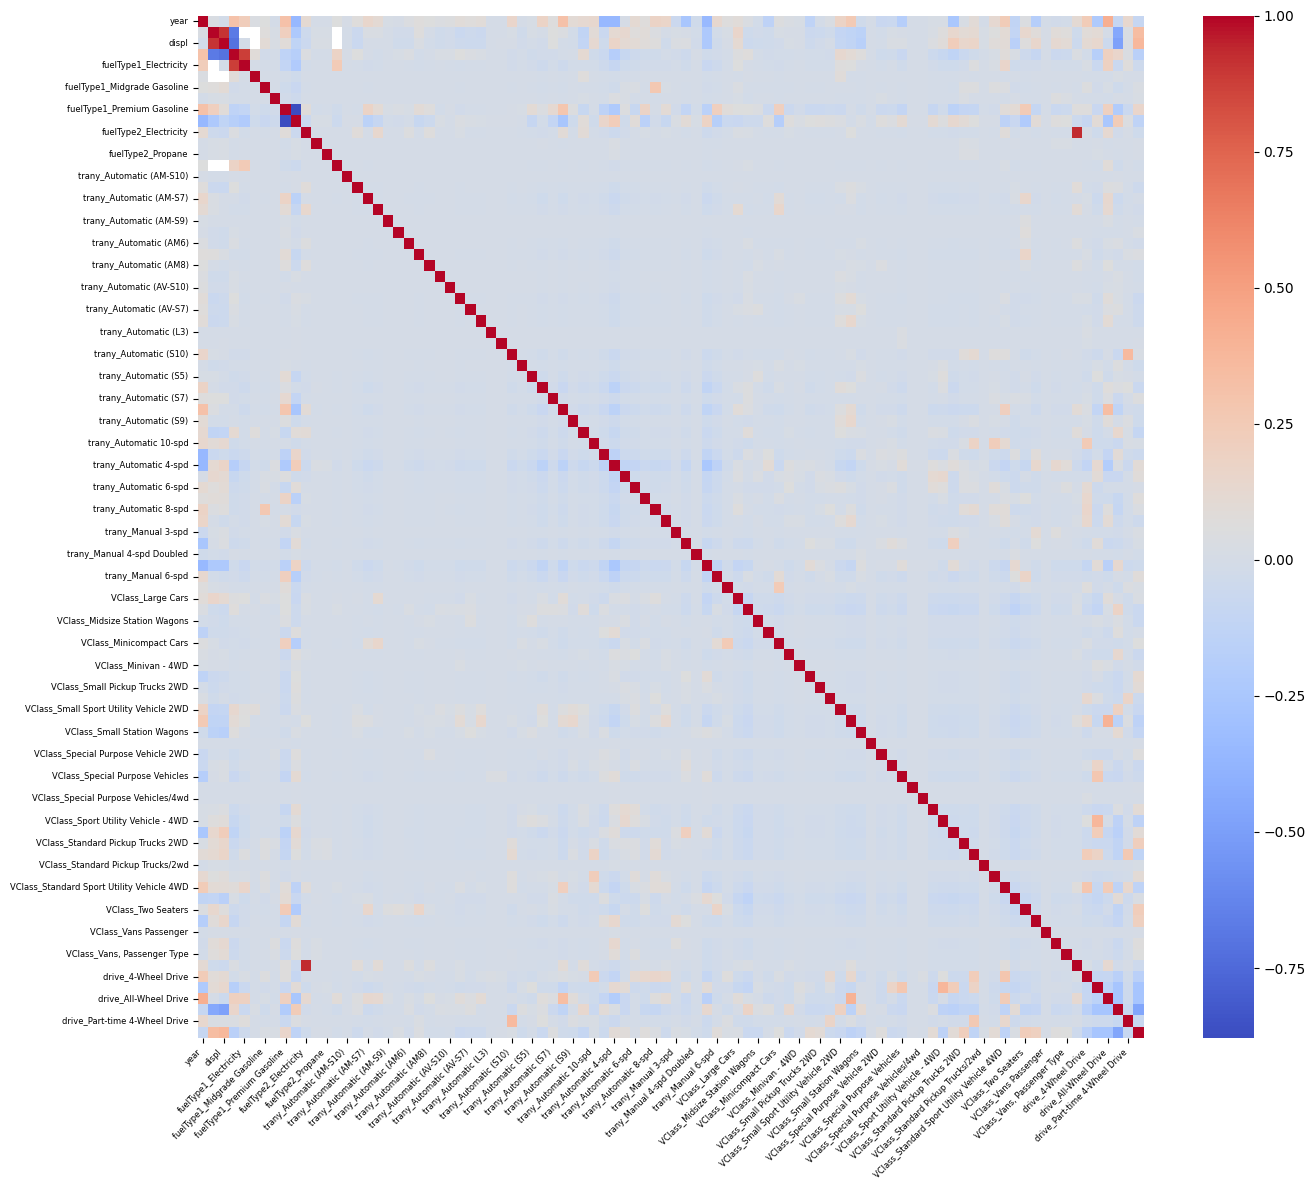

Now a graph where only strongest correlations are present for better readability



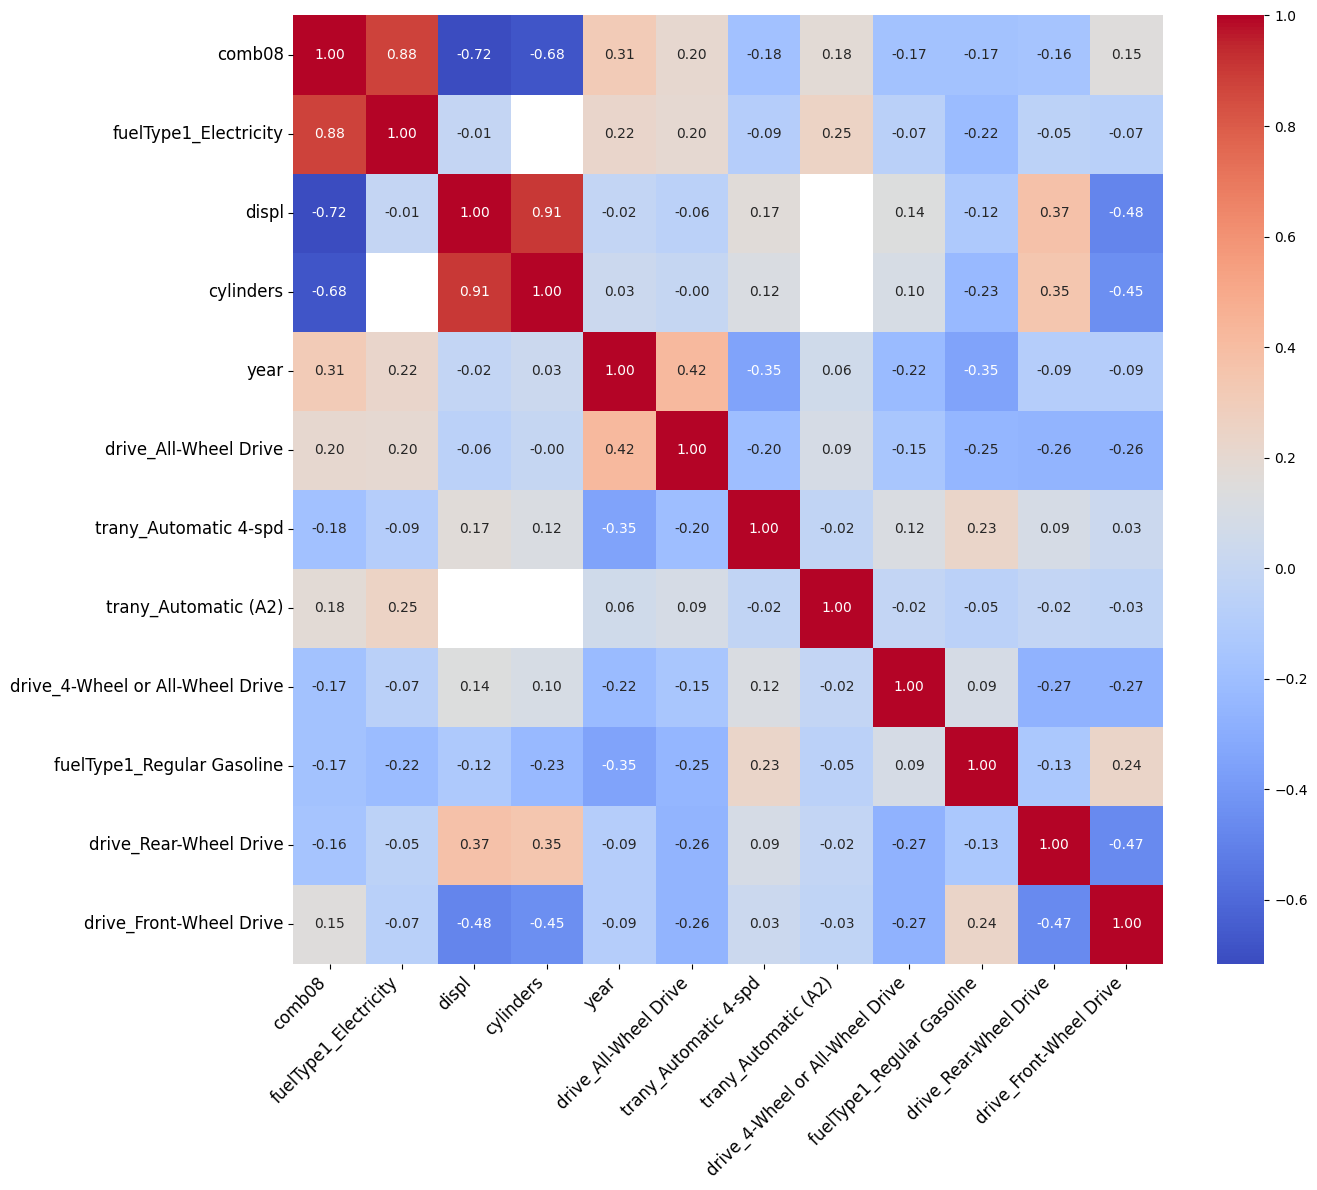

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/vehicles.csv", low_memory=False)

# Clean target
df = df.dropna(subset=["comb08"])
df = df[df["comb08"] > 0]

# Select reduced feature set
selected_cols = [
    "year",
    "fuelType1",
    "fuelType2",
    "trany",
    "VClass",
    "phevBlended",
    "cylinders",
    "displ",
    "drive"
]

df_small = df[selected_cols + ["comb08"]].copy()

# Encode categorical columns
categorical_cols = df_small.select_dtypes(include=["object", "bool"]).columns.tolist()
if "comb08" in categorical_cols:
    categorical_cols.remove("comb08")

df_encoded = pd.get_dummies(df_small, columns=categorical_cols, drop_first=True)

#compute correlation matrix
corr_matrix = df_encoded.corr()

#reduce to strongest correlations for readability
corr_with_target = corr_matrix["comb08"].abs().sort_values(ascending=False)
top_features = corr_with_target.head(12).index
corr_filtered = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    fmt=".2f"
)

plt.xticks(rotation=45, ha="right", fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

print("Now a graph where only strongest correlations are present for better readability\n")

plt.figure(figsize=(14,12))

sns.heatmap(
    corr_filtered,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


### Using ANOVA F-Statictics as another way to find high correlation. It basically finds the ratio of variance due to the feature we're checking over the variance due to residuals

/tmp/ipykernel_6423/965028129.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = X[col].astype("object").fillna("__MISSING__")


Top 20 features by F-statistic:
       Feature        F_stat
0    charge240  98470.198812
1    rangeCity  78742.081538
2     rangeHwy  77304.294372
3     highwayE  40980.815810
4        range  38778.020014
5        combE  37014.445968
6        cityE  33580.839003
7    fuelType1  27632.546398
8     ghgScore  24217.234003
9      feScore  22861.308938
10     atvType  19779.047721
11    fuelType  11848.844453
12       displ   5894.793589
13        year   5263.113111
14  charge240b   4604.301877
15   cylinders   3445.594321
16   startStop   3155.051231
17    c240Dscr   2415.295673
18   c240bDscr   1572.597077
19         hpv   1006.213584


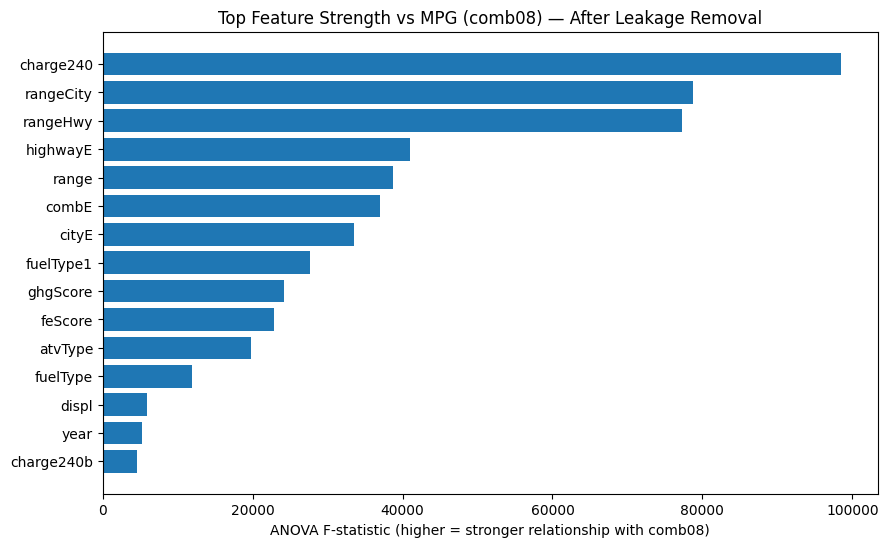

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_regression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

df = pd.read_csv("/content/vehicles.csv", low_memory=False)


# Target clean
TARGET = "comb08"
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.dropna(subset=[TARGET])
df = df[df[TARGET] > 0]

# Replace inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

#drop known leakage / MPG-derived columns
LEAKAGE_COLS = [
    # MPG components / variants (fuelType1)
    "city08", "highway08",
    "city08U", "highway08U",
    "comb08U",
    "UCity", "UHighway",
# derived consumption/cost/emissions based on MPG
    "barrels08", "fuelCost08", "youSaveSpend",
    "co2", "co2TailpipeGpm",
    "co2TailpipeAGpm", "co2TailpipeGpm-"
]
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# drop very high cardinality columns to avoid huge dummy expansion
HIGH_CARD = ["model", "make", "basemodel", "baseModel", "eng_dscr", "trans_dscr", "emissionsList", "efid", "mfrCode", "id"]
df = df.drop(columns=[c for c in HIGH_CARD if c in df.columns], errors="ignore")


# y and feature type split
y = df[TARGET]
X = df.drop(columns=[TARGET])

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

#numeric: impute NaNs then F-test
num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(num_imputer.fit_transform(X[numeric_cols]), columns=numeric_cols)

F_num, _ = f_regression(X_num, y)
numeric_scores = dict(zip(numeric_cols, F_num))

#categorical: one-hot per feature, then mean F-stat
categorical_scores = {}
for col in categorical_cols:
    s = X[col].astype("object").fillna("__MISSING__")

    encoded = pd.get_dummies(s, drop_first=True)
    if encoded.shape[1] == 0:
        continue

    F_vals, _ = f_regression(encoded, y)
    categorical_scores[col] = float(np.mean(F_vals))

# Combine + Rank
all_scores = {**numeric_scores, **categorical_scores}
scores_df = (
    pd.DataFrame(sorted(all_scores.items(), key=lambda x: x[1], reverse=True),
                 columns=["Feature", "F_stat"])
)

print("Top 20 features by F-statistic:")
print(scores_df.head(20))


# Plot Top N (we chose 15 in this case)
top_n = 15
top = scores_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top["Feature"][::-1], top["F_stat"][::-1])
plt.xlabel("ANOVA F-statistic (higher = stronger relationship with comb08)")
plt.title("Top Feature Strength vs MPG (comb08) — After Leakage Removal")
plt.show()


# Exploratory Data Analysis



Raw shape: (49580, 84)
Cleaned shape: (49580, 17)


/tmp/ipykernel_6423/2796724083.py:15: DtypeWarning: Columns (69,71,72,73,74,75,77,80) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicles_df = pd.read_csv(csv_path)


,year,city08,highway08,comb08,cylinders,displ,co2TailpipeGpm,fuelCost08,ghgScore,hpv
count,49580.000000,49580.000000,49580.000000,49580.000000,48209.000000,48211.000000,49580.000000,49580.000000,49580.000000,49580.000000
mean,2005.178035,20.593566,26.328862,22.673235,5.693273,3.264747,445.931323,2485.054457,1.217144,9.516156
std,12.973479,14.401056,12.275861,13.344365,1.773855,1.350116,140.857333,783.359211,3.257414,27.214014
min,1984.000000,6.000000,9.000000,7.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,1993.000000,15.000000,20.000000,17.000000,4.000000,2.100000,370.291667,2000.000000,-1.000000,0.000000
50%,2006.000000,18.000000,24.000000,20.000000,6.000000,3.000000,444.350000,2450.000000,-1.000000,0.000000
75%,2017.000000,21.000000,29.000000,24.000000,6.000000,4.200000,522.764706,2950.000000,4.000000,0.000000
max,2026.000000,153.000000,142.000000,146.000000,16.000000,8.400000,1269.571429,8350.000000,10.000000,195.000000


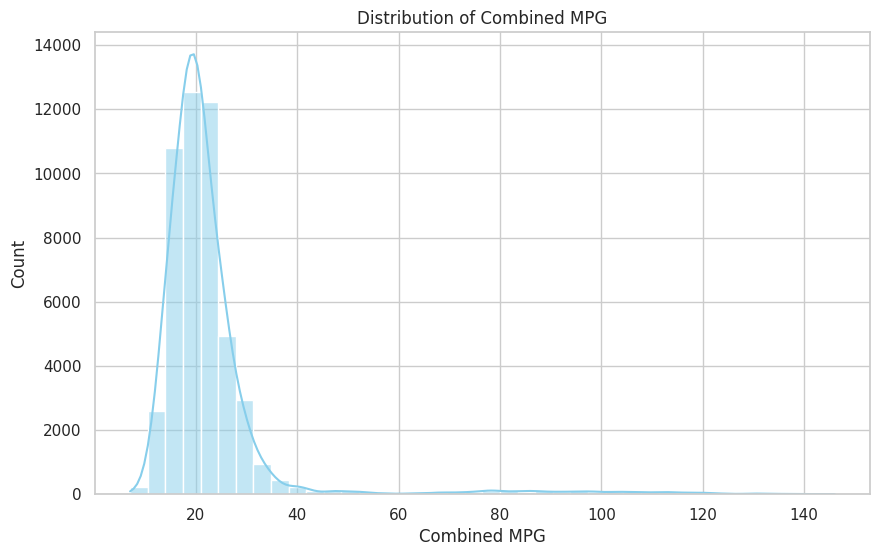

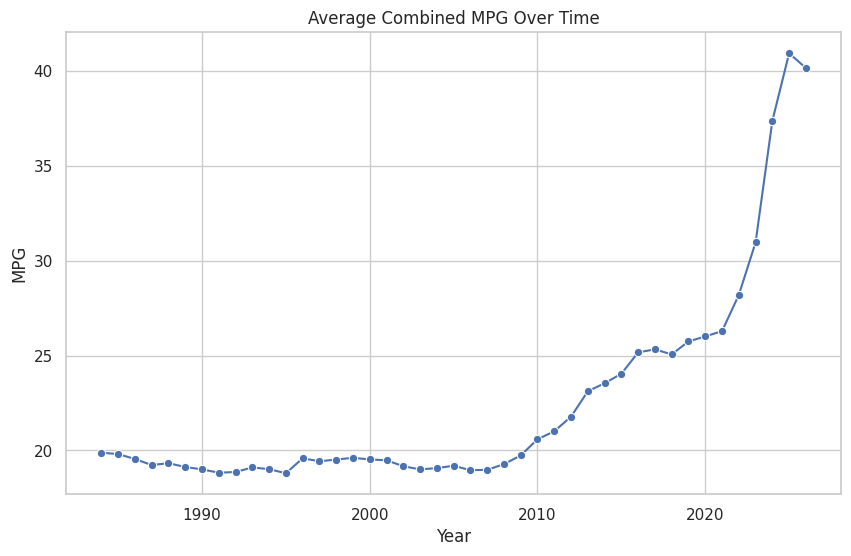

/tmp/ipykernel_6423/2796724083.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vehicles_df, x="fuelType1", y="comb08", palette="pastel")


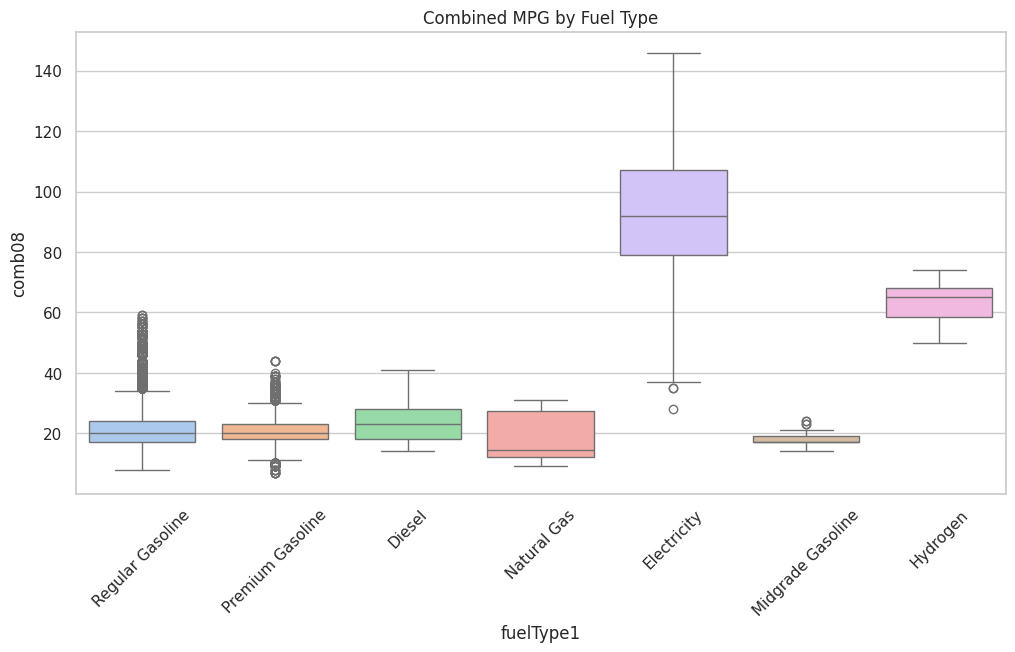

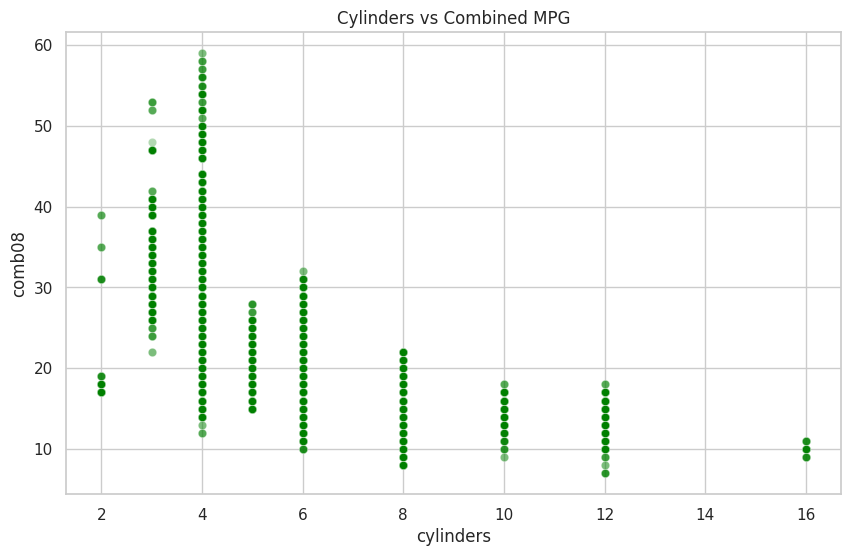

/tmp/ipykernel_6423/2796724083.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


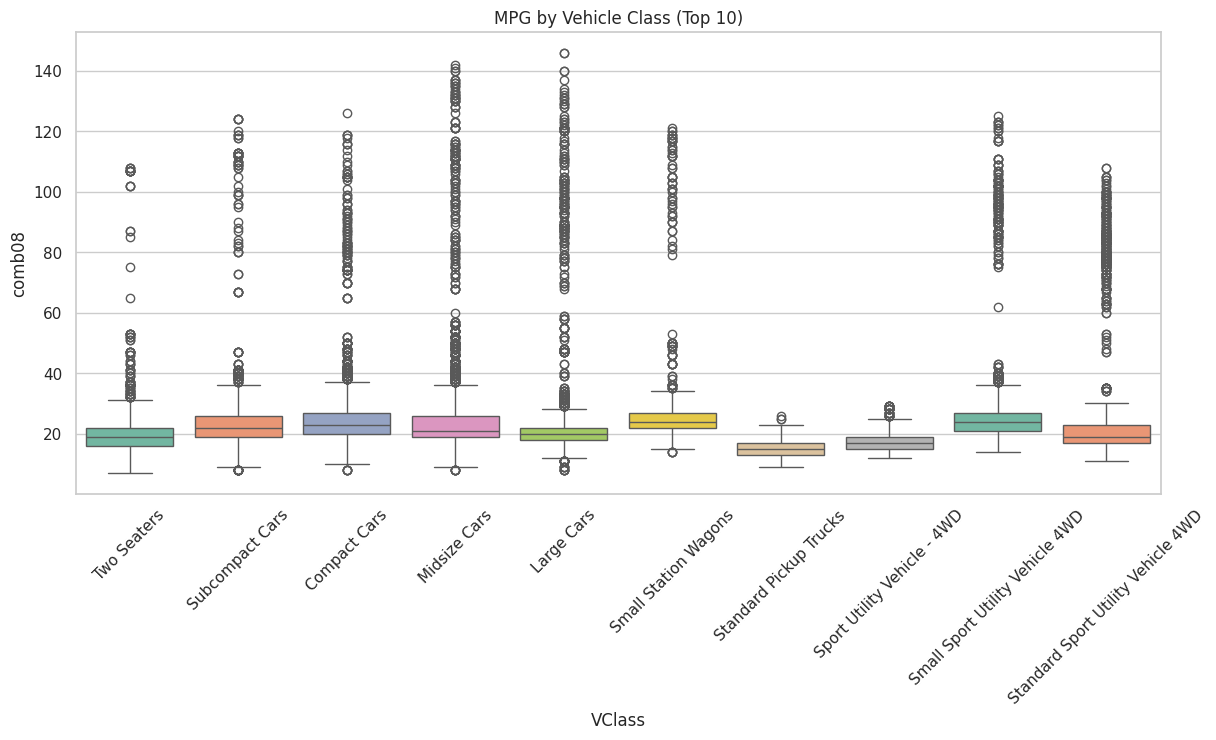

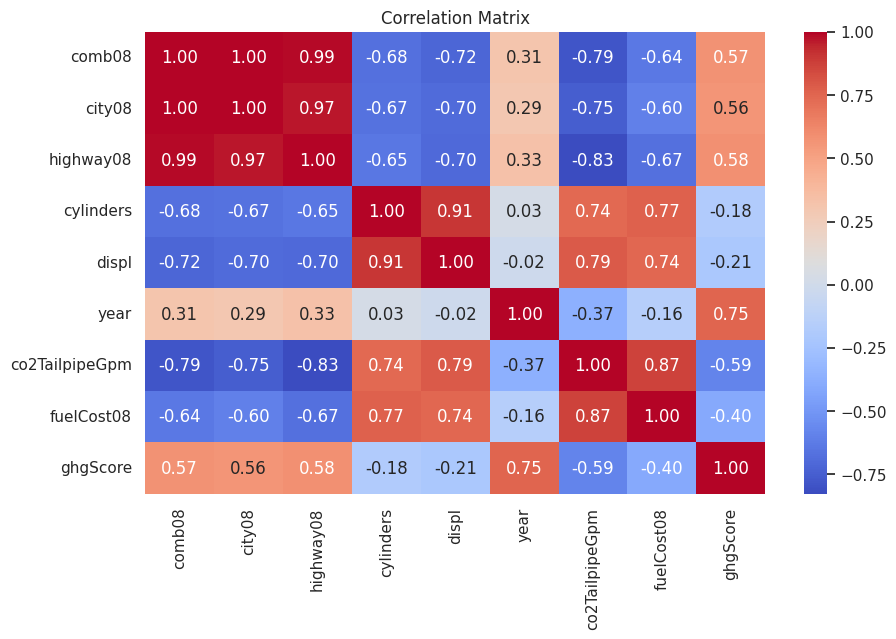

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import zipfile
import io

pd.set_option("display.max_columns", 200)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

csv_path = "vehicles.csv"

# Load
vehicles_df = pd.read_csv(csv_path)
print("Raw shape:", vehicles_df.shape)
vehicles_df.head()

# Column's with Best Data
# columns_to_keep = [
#     "year", "make", "model", "VClass",
#     "fuelType", "fuelType1",
#     "city08", "highway08", "comb08",
#     "cylinders", "displ",
#     "trany", "drive"
# ]


columns_to_keep = [
    # identifiers / categories (for later modeling & plots)
    "year", "make", "model", "VClass",
    "fuelType", "fuelType1",
    "trany", "drive",

    # MPG metrics (EDA only, leakage later)
    "city08", "highway08", "comb08",

    # engine / numeric predictors
    "cylinders", "displ",

    # extra numeric variables useful for EDA + explanation
    "co2TailpipeGpm", "fuelCost08", "ghgScore", "hpv"
]
vehicles_df = vehicles_df[columns_to_keep].copy()

numeric_columns = ["city08", "highway08", "comb08", "cylinders", "displ",
                   "co2TailpipeGpm", "fuelCost08", "ghgScore"]
for column in numeric_columns:
    vehicles_df[column] = pd.to_numeric(vehicles_df[column], errors="coerce")

vehicles_df = vehicles_df.dropna(subset=["comb08"])
vehicles_df["year"] = vehicles_df["year"].astype(int)

print("Cleaned shape:", vehicles_df.shape)

# Dataset w/following EDA's
display(vehicles_df.describe())

# Distrubution of MPG
plt.figure()
sns.histplot(vehicles_df["comb08"], bins=40, kde=True, color="skyblue")
plt.title("Distribution of Combined MPG")
plt.xlabel("Combined MPG")
plt.ylabel("Count")
plt.show()

# MPG Over Time
average_mpg_by_year = vehicles_df.groupby("year")["comb08"].mean().reset_index()

plt.figure()
sns.lineplot(data=average_mpg_by_year, x="year", y="comb08", marker="o")
plt.title("Average Combined MPG Over Time")
plt.ylabel("MPG")
plt.xlabel("Year")
plt.show()

# MPG vs Fuel Type
plt.figure(figsize=(12,6))
sns.boxplot(data=vehicles_df, x="fuelType1", y="comb08", palette="pastel")
plt.xticks(rotation=45)
plt.title("Combined MPG by Fuel Type")
plt.show()

# No. of Cylinders vs MPG
plt.figure()
sns.scatterplot(
    data=vehicles_df,
    x="cylinders",
    y="comb08",
    alpha=0.3,
    color="green"
)
plt.title("Cylinders vs Combined MPG")
plt.show()

# Top 10 Vehicle Comparisons
top_vehicle_classes = vehicles_df["VClass"].value_counts().head(10).index

plt.figure(figsize=(14,6))
sns.boxplot(
    data=vehicles_df[vehicles_df["VClass"].isin(top_vehicle_classes)],
    x="VClass",
    y="comb08",
    palette="Set2"
)
plt.xticks(rotation=45)
plt.title("MPG by Vehicle Class (Top 10)")
plt.show()

# Heatmap
heatmap_cols = ["comb08", "city08", "highway08", "cylinders", "displ",
                "year", "co2TailpipeGpm", "fuelCost08", "ghgScore"]
plt.figure()
sns.heatmap(
    vehicles_df[heatmap_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [ ]:
### THESE ARE RATIOS THAT WE CAN USE FOR FEATURE SELECTION

import numpy as np
# Avoid division by zero
vehicles_df = vehicles_df.replace(0, np.nan)

# Create ratio features
vehicles_df["hp_per_liter"] = vehicles_df["hpv"] / vehicles_df["displ"]
vehicles_df["hp_per_cyl"] = vehicles_df["hpv"] / vehicles_df["cylinders"]
vehicles_df["co2_per_hp"] = vehicles_df["co2TailpipeGpm"] / vehicles_df["hpv"]
vehicles_df["fuelcost_per_hp"] = vehicles_df["fuelCost08"] / vehicles_df["hpv"]
vehicles_df["liter_per_cyl"] = vehicles_df["displ"] / vehicles_df["cylinders"]

# Drop NaNs created from division
vehicles_df = vehicles_df.dropna(subset=[
    "hp_per_liter",
    "hp_per_cyl",
    "co2_per_hp",
    "fuelcost_per_hp",
    "liter_per_cyl"
])

#The ratios that we are experimenting with
ratio_cols = [
    "hp_per_liter",
    "hp_per_cyl",
    "co2_per_hp",
    "fuelcost_per_hp",
    "liter_per_cyl"
]

print(vehicles_df[ratio_cols + ["comb08"]].corr()["comb08"])

hp_per_liter       0.656883
hp_per_cyl         0.481204
co2_per_hp        -0.801185
fuelcost_per_hp   -0.734531
liter_per_cyl     -0.519753
comb08             1.000000
Name: comb08, dtype: float64


# Feature Selection

In [ ]:
print(vehicles_df.columns)

Index(['year', 'make', 'model', 'VClass', 'fuelType', 'fuelType1', 'trany',
       'drive', 'city08', 'highway08', 'comb08', 'cylinders', 'displ',
       'co2TailpipeGpm', 'fuelCost08', 'ghgScore', 'hpv', 'hp_per_liter',
       'hp_per_cyl', 'co2_per_hp', 'fuelcost_per_hp', 'liter_per_cyl'],
      dtype='object')


In [ ]:
import numpy as np

#Target variable
target = "comb08"

#This is to remove leakage variables based on analysis from correlation matrix
#I am making a copy to ensure our original model isn't impacted in future iterations
#city08 and highway08 are directly correlated with comb08 (target variable)
model_df = vehicles_df.copy()
model_df = model_df.drop(columns=["city08", "highway08"])

#avoiding dividing by zero
model_df = model_df.replace (0, np.nan)

# ratio features
model_df["hp_per_liter"] = model_df["hpv"] / model_df["displ"]
model_df["liter_per_cyl"] = model_df["displ"] / model_df["cylinders"]
model_df["hp_per_cyl"] = model_df["hpv"] / model_df["cylinders"]

#The columns of ratios
ratio_cols = ["hp_per_liter", "liter_per_cyl", "hp_per_cyl"]

# dropped rows where ratios couldn't be computed (edge case)
model_df = model_df.dropna(subset=ratio_cols + [target])

# Chose the colums that could be correlated
numeric_cols = ["year", "cylinders", "displ", "co2TailpipeGpm", "fuelCost08", "ghgScore"]

#computing the absolute correlation matrix
corr_matrix = model_df[numeric_cols].corr().abs()

#This uses the upper triangle to avoid duplicate pairs
#documentation: https://numpy.org/doc/stable/reference/generated/numpy.triu.html
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(abs(upper[col]) > 0.6)] #This identifies columns with correlation above threshold 0.6


#Results
print("Highly correlated columns:", high_corr)

print ("We are keeping both cylinders and displ since Elastic Net can handle correlation. They represent multicollinearity.")

# Final selected features
selected_features = ["year", "cylinders", "displ", "drive", "trany", "VClass", "fuelType1"] + ratio_cols

print("Final features:", selected_features)




Highly correlated columns: ['displ', 'co2TailpipeGpm', 'fuelCost08', 'ghgScore']
We are keeping both cylinders and displ since Elastic Net can handle correlation. They represent multicollinearity.
Final features: ['year', 'cylinders', 'displ', 'drive', 'trany', 'VClass', 'fuelType1', 'hp_per_liter', 'liter_per_cyl', 'hp_per_cyl']


### Feature Selection Explanation

We selected comb08 as our targeted variable because we are trying to calculate combined MPG using a variety of feature sets.

To avoid data leakage, we removed city08 and highway08 from the dataset because combined MPG is directly correlated with these two variables of correlation 1. Including these would mean that the model would reconstruct the target variable, leading to artificial results.

Then, we explored multicollinearity among predictors using a correlation matrix. Using a threshold of |r| > 0.6, we identified strongly correlated variables such as cylinders and displ, co2TailpipGpm and fuelCost08, and ghgScore and emission-related variables.

These relationships indicate multicollinearity. Since we are using Elastic Net regularization, it's designed to handle correlated predictors by shrinking coefficients. This is why we chose not to drop these variables.

Our final selected features for modeling are year, cylinders, displ, drive, trany, VClass, and fuelType1.

These features capture engine details, vehicle design, drivetrain configuration, and fuel type. These are all important predictors of fuel efficiency, while avoiding direct leakage from city and highway MPG variables.

We also generated five ratios that were engineering features and evaluated multicollinearity using a correlation threadhold of r > 0.6. These ratios were moderately correlated, and we retained them because Elastic Net regularization is designed to handle correlated predictors.

We generated these ratios to better capture efficiency-based relationships rather than absolute engine size measures. For example, horsepower per liter reflected engine efficiency, CO2 per horsepower reflected emission intensity, nad fuel cost per horsepower reflected economic efficiency. These ratios help allow the model to learn better performance metrics that raw variables can't fully capture.

Ratio feature may be needed to be evaluated during model performance evaluation as it can introduce additional variance.

We also excluded fueltype2 during preprocessing because it contained many missing values and is largely reduntant with fueltype1. It also contains information about electric vehicles, which would potentially skew the data. Most vehicles in the dataset only report a primary fuel type, so including fuelType2 would introduce sparsity without adding much predictive value.

# Base Model Implementation

In [ ]:
# Preprocess data, split train/test, provide eval helper, and fit a mean-predicting baseline

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
import numpy as np

# Split features/target
X = model_df[selected_features]
y = model_df[target]

# Define feature groups
numeric_features = ["year", "cylinders", "displ"] + ratio_cols
categorical_features = ["drive", "trany", "VClass", "fuelType1"]

# Preprocessing: impute, scale numeric; impute + one-hot encode categorical
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


def evaluate_model(y_true, y_pred):
    """Return and print common regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    # Calculate RMSE manually by taking the square root of MSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R^2: {r2:.3f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

# Simple baseline: always predicts the training-set mean
dummy_model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", DummyRegressor(strategy="mean")),
])
dummy_model.fit(X_train, y_train)
baseline_enet = Pipeline([
    ("preprocess", preprocess),
    ("regressor", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)),
])
baseline_enet.fit(X_train, y_train)
enet_base_pred = baseline_enet.predict(X_test)
enet_base_metrics = evaluate_model(y_test, enet_base_pred)
enet_base_metrics

MAE: 2.337
RMSE: 3.465
R^2: 0.682


{'mae': 2.3367304171084027,
 'rmse': np.float64(3.465371118798304),
 'r2': 0.6816494330532807}

# Base Implementation [Elastic Net]



In [ ]:
from sklearn.linear_model import ElasticNet

# Baseline Elastic Net (lightly regularized)
baseline_model = Pipeline(
    steps=[
        (
            "preprocess",
            preprocess
        ),
        (
            "regressor",
            ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)
        ),
    ]
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
print(baseline_model.named_steps["regressor"].n_iter_)
baseline_metrics = evaluate_model(y_test, baseline_pred)
baseline_metrics

43
MAE: 2.337
RMSE: 3.465
R^2: 0.682


{'mae': 2.3367304171084027,
 'rmse': np.float64(3.465371118798304),
 'r2': 0.6816494330532807}

# Implementation #1 (Hyperparameter-Tuned Elastic Net)



In [ ]:
from sklearn.model_selection import GridSearchCV

# Implementation #1: hyperparameter-tuned Elastic Net
param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

grid_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("regressor", ElasticNet(max_iter=5000, random_state=42)),
        ]
    ),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print(f"CV RMSE: {-grid_search.best_score_:.3f}")

best_elastic_net = grid_search.best_estimator_
impl1_pred = best_elastic_net.predict(X_test)

impl1_metrics = evaluate_model(y_test, impl1_pred)
impl1_metrics

Best params: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.9}
CV RMSE: 3.001
MAE: 1.899
RMSE: 2.774
R^2: 0.796


{'mae': 1.8988688591790308,
 'rmse': np.float64(2.7736504949067218),
 'r2': 0.796056628403427}

# Implementation #2 (Lasso)



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
import numpy as np

#preprocessing + lass model
lasso = Pipeline(
    steps=[
        ("preprocess", preprocess), #handles scaling
        ("regressor", Lasso(max_iter=20000, random_state=42)),
    ]
)

#regularization strength is represented by alpha
lasso_parameters = {
    "regressor__alpha": np.logspace(-4, 2, 15)
}


#5 - fold CV usig RMSE as metric
lasso_search = GridSearchCV(
    lasso,
    param_grid=lasso_parameters,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

#training and tuning
lasso_search.fit(X_train, y_train)

print("Best Lasso parameters:", lasso_search.best_params_)

#predict with best model
lasso_pred = lasso_search.predict(X_test)

#evaluate model on unseen test data
lasso_metrics = evaluate_model(y_test, lasso_pred)
lasso_metrics

Best Lasso parameters: {'regressor__alpha': np.float64(0.00026826957952797245)}
MAE: 1.896
RMSE: 2.770
R^2: 0.797


{'mae': 1.8962922455612987,
 'rmse': np.float64(2.7698904420816066),
 'r2': 0.7966091984381158}

# Implementation #3 (Ridge)



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import numpy as np

#crates pipeline for preproccessing + ridge regression
#transformations are applied inside CV
ridge = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", Ridge(random_state=42)),
    ]
)

#defines hyperparameters
ridge_parameters = {
    "regressor__alpha": np.logspace(-4, 4, 15)
}

#Set up GridSearch w 5-fold cross validation
ridge_search = GridSearchCV(
    ridge,
    param_grid=ridge_parameters,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

#train model and complete hyperparameter tuning
ridge_search.fit(X_train, y_train)

print("Best Ridge parameters:", ridge_search.best_params_)
print("Best CV RMSE:", -ridge_search.best_score_)

#extracts best performing model
best_ridge = ridge_search.best_estimator_
#generates prediction on test set
ridge_pred = best_ridge.predict(X_test)

#evaluate final performance on test data
ridge_metrics = evaluate_model(y_test, ridge_pred)
ridge_metrics

Best Ridge parameters: {'regressor__alpha': np.float64(0.2682695795279725)}
Best CV RMSE: 2.999727185796738
MAE: 1.896
RMSE: 2.769
R^2: 0.797


{'mae': 1.8956329500070122,
 'rmse': np.float64(2.7689125093535703),
 'r2': 0.7967527906945585}

In [ ]:
# Dummy
dummy_pred = dummy_model.predict(X_test)
dummy_metrics = evaluate_model(y_test, dummy_pred)

# Base ElasticNet (fixed alpha/l1_ratio)
enet_base_pred = baseline_enet.predict(X_test)
enet_base_metrics = evaluate_model(y_test, enet_base_pred)

# Tuned ElasticNet (GridSearchCV best_estimator_)
enet_tuned_pred = best_elastic_net.predict(X_test)
enet_tuned_metrics = evaluate_model(y_test, enet_tuned_pred)

# Lasso
lasso_pred = lasso_search.predict(X_test)
lasso_metrics = evaluate_model(y_test, lasso_pred)

# Ridge
ridge_pred = ridge_search.predict(X_test)
ridge_metrics = evaluate_model(y_test, ridge_pred)

MAE: 4.643
RMSE: 6.142
R^2: -0.000
MAE: 2.337
RMSE: 3.465
R^2: 0.682
MAE: 1.899
RMSE: 2.774
R^2: 0.796
MAE: 1.896
RMSE: 2.770
R^2: 0.797
MAE: 1.896
RMSE: 2.769
R^2: 0.797


In [ ]:
results = pd.DataFrame([
    {"model": "Dummy", **dummy_metrics},
    {"model": "ElasticNet(base)", **enet_base_metrics},
    {"model": "ElasticNet(tuned)", **enet_tuned_metrics},
    {"model": "Lasso", **lasso_metrics},
    {"model": "Ridge", **ridge_metrics},
])

results

,model,mae,rmse,r2
0,Dummy,4.643099,6.142119,-0.000098
1,ElasticNet(base),2.336730,3.465371,0.681649
2,ElasticNet(tuned),1.898869,2.773650,0.796057
3,Lasso,1.896292,2.769890,0.796609
4,Ridge,1.895633,2.768913,0.796753


# LightGBM/Catboost/Random Forest



In [ ]:
!pip install lightgbm

Features being used:
Index(['year', 'cylinders', 'displ', 'drive', 'trany', 'VClass', 'fuelType1',
       'hp_per_liter', 'liter_per_cyl', 'hp_per_cyl'],
      dtype='object')
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 4207, number of used features: 41
[LightGBM] [Info] Start training from score 25.235797
Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': -1, 'regressor__n_estimators': 500, 'regressor__num_leaves': 50}
LightGBM Test RMSE: 1.2028648799906
LightGBM Test MAE: 0.7746921264884133
LightGBM Test R2: 0.961643425529736


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


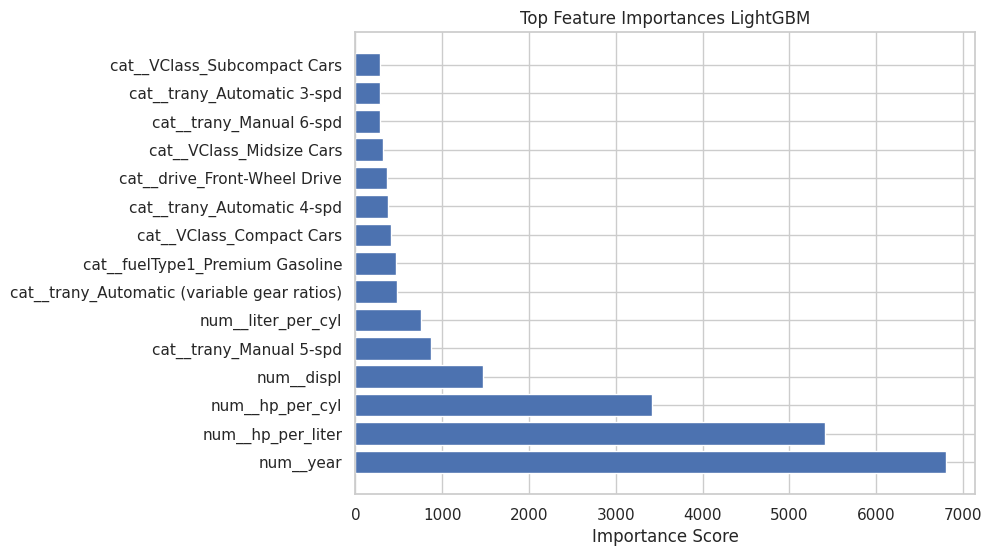

Train R2: 0.9824284949971313
Test R2: 0.961643425529736
Test RMSE 1.2028648799906
Train RMSE 0.8529380288616576


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# features without leakage
selected_features = ["year", "cylinders", "displ", "drive", "trany", "VClass", "fuelType1","hp_per_liter", "liter_per_cyl", "hp_per_cyl"]
X = model_df[selected_features]
y = model_df[target]
print("Features being used:")
print(X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
numeric_features = ["year","cylinders","displ","hp_per_liter","liter_per_cyl","hp_per_cyl"]
categorical_features = ["drive","trany","VClass","fuelType1"]

# adding this code here so it can run in one isolated container
preprocess = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
lgb_model = lgb.LGBMRegressor(random_state=42)
lgbm_pipeline = Pipeline(steps=[('preprocess', preprocess),('regressor', lgb_model)])
# grid search from above
param_grid = {'regressor__n_estimators': [200, 500],'regressor__learning_rate': [0.05, 0.1],'regressor__max_depth': [-1, 10, 20],'regressor__num_leaves': [31, 50]}
# k=5 fold cross validation
grid_lgb = GridSearchCV(estimator=lgbm_pipeline,param_grid=param_grid,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1,verbose=1)
grid_lgb.fit(X_train, y_train)
best_lgb = grid_lgb.best_estimator_
print("Best Parameters:", grid_lgb.best_params_)
y_pred_lgb = best_lgb.predict(X_test) #metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae = mean_absolute_error(y_test, y_pred_lgb)
r2 = r2_score(y_test, y_pred_lgb)
print("LightGBM Test RMSE:", rmse)
print("LightGBM Test MAE:", mae)
print("LightGBM Test R2:", r2)

importances = best_lgb.named_steps['regressor'].feature_importances_
transformed_feature_names = best_lgb.named_steps['preprocess'].get_feature_names_out()

#plotting features
importance_df = pd.DataFrame({'Feature': transformed_feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
num_features_to_plot = min(15, len(importance_df))
plt.barh(importance_df['Feature'][:num_features_to_plot][::-1], importance_df['Importance'][:num_features_to_plot][::-1])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances LightGBM")
plt.xlabel("Importance Score")
plt.show()
y_train_pred = best_lgb.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred_lgb)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Test RMSE", test_rmse)
print("Train RMSE", train_rmse)

# XG Boost



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
!pip install xgboost
from xgboost import XGBRegressor

csv_path = "vehicles.csv"
df = pd.read_csv(csv_path)

target = "comb08"

selected_features = [
    "year",
    "cylinders",
    "displ",
    "drive",
    "trany",
    "VClass",
    "fuelType1",
]

df = df[selected_features + [target]].dropna()

df = pd.get_dummies(df, columns=["drive", "trany", "VClass", "fuelType1"], drop_first=True)

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_distributions = {
    "n_estimators": np.arange(300, 2000, 100),
    "learning_rate": np.linspace(0.01, 0.2, 100),
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": np.linspace(0.6, 1.0, 10),
    "colsample_bytree": np.linspace(0.6, 1.0, 10),
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2, 3],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="r2",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best CV R2:", search.best_score_)
print("Best Params:", search.best_params_)
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)


/tmp/ipykernel_6423/539028708.py:10: DtypeWarning: Columns (69,71,72,73,74,75,77,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV R2: 0.9366635918617249
Best Params: {'subsample': np.float64(1.0), 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': np.int64(1500), 'max_depth': 10, 'learning_rate': np.float64(0.13090909090909092), 'gamma': 0.1, 'colsample_bytree': np.float64(0.6)}
Test MAE: 0.8745614290237427
Test RMSE: 1.3615127066174453
Test R2: 0.9434503316879272

Feature Importance:
cylinders                                 0.093586
trany_Automatic (variable gear ratios)    0.085372
trany_Automatic (AV-S6)                   0.073478
trany_Automatic (AM-S6)                   0.055531
displ                                     0.052069
                                            ...   
trany_Automatic (AM-S9)                   0.000000
trany_Automatic (L4)                      0.000000
VClass_Special Purpose Vehicles/4wd       0.000000
VClass_Special Purpose Vehicles/2wd       0.000000
VClass_Vans Passenger                     0.000000
Length: 83, dtype: float32


# Model Testing



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.dummy import DummyRegressor
!pip install lightgbm
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


base_selected_features = ["year", "cylinders", "displ", "drive", "trany", "VClass", "fuelType1"] + ratio_cols
X_raw = model_df[base_selected_features].copy()
y_raw = model_df[target].copy()

def _metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def build_models():
    models = {}
    models["Dummy"] = Pipeline([("preprocess", preprocess), ("regressor", DummyRegressor(strategy="mean"))])
    models["Ridge"] = Pipeline([("preprocess", preprocess), ("regressor", Ridge(alpha=ridge_search.best_params_["regressor__alpha"]))])
    models["Lasso"] = Pipeline([("preprocess", preprocess), ("regressor", Lasso(alpha=lasso_search.best_params_["regressor__alpha"]))])
    models["ElasticNet_Base"] = Pipeline([("preprocess", preprocess), ("regressor", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42))])
    models["ElasticNet_Tuned"] = Pipeline([("preprocess", preprocess), ("regressor", ElasticNet(alpha=grid_search.best_params_["regressor__alpha"], l1_ratio=grid_search.best_params_["regressor__l1_ratio"], max_iter=5000, random_state=42))])
    models["LightGBM"] = Pipeline([("preprocess", preprocess), ("regressor", lgb.LGBMRegressor(**{k.replace('regressor__', ''): v for k, v in grid_lgb.best_params_.items()}, random_state=42, verbose=-1))])
    models["XGBoost"] = Pipeline([("preprocess", preprocess), ("regressor", XGBRegressor(**search.best_params_, random_state=42))])
    return models

N_RUNS = 100
results = []
models = build_models()

for seed in range(N_RUNS):
    X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=seed)
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mae, rmse, r2 = _metrics(y_test, preds)
        results.append({"run": seed, "model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
summary = results_df.groupby("model")[["MAE", "RMSE", "R2"]].mean().sort_values("RMSE")
display(summary)
print("\nCompleted runs for:", sorted(results_df["model"].unique()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4957.743596230164, tolerance: 16.892286094604234
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4614.369810987893, tolerance: 17.161578844782497
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/pyt

,MAE,RMSE,R2
model,,,
XGBoost,0.801802,1.280703,0.959104
LightGBM,0.801975,1.283991,0.958872
Ridge,1.983193,2.935685,0.786331
Lasso,1.982906,2.935825,0.786309
ElasticNet_Tuned,1.983201,2.938638,0.785911
ElasticNet_Base,2.437025,3.735128,0.654558
Dummy,4.688124,6.358232,-0.001406



Completed runs for: ['Dummy', 'ElasticNet_Base', 'ElasticNet_Tuned', 'Lasso', 'LightGBM', 'Ridge', 'XGBoost']


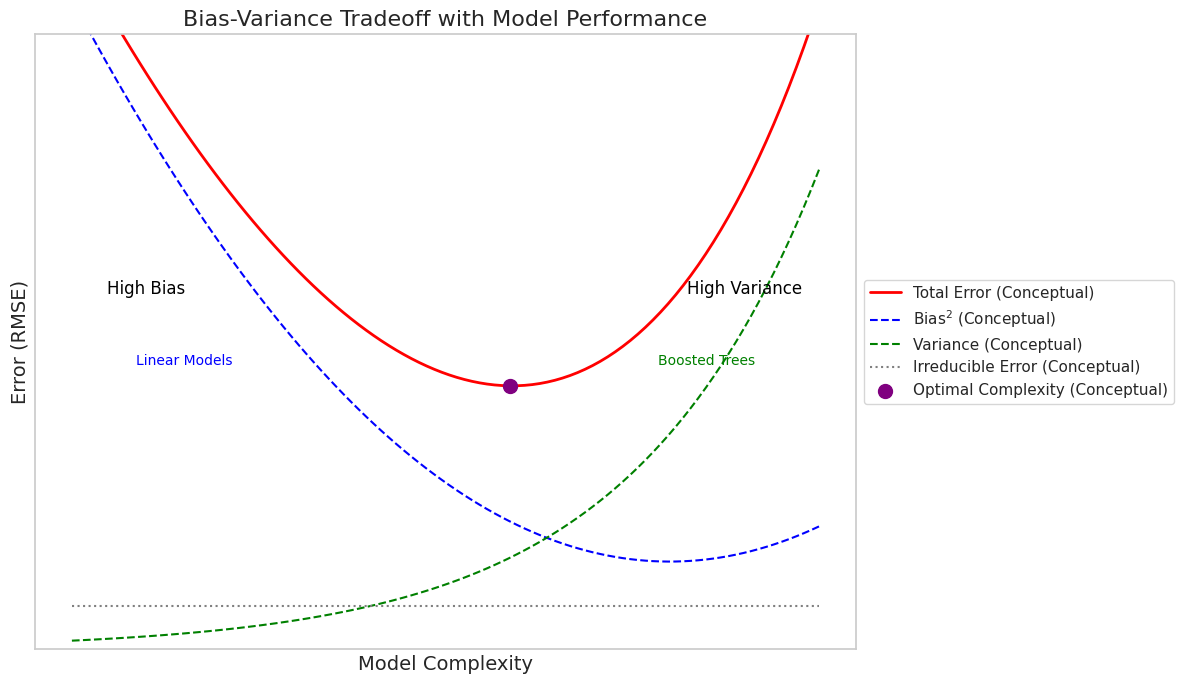

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7)) # Increased figure size for better readability

# model complexity range
x = np.linspace(0, 10, 100)

# Conceptual curves
bias_squared = (x - 8)**2 / 10 + 1  # Example for bias
variance = np.exp(x/2.5) / 10      # Example for variance
noise = np.full_like(x, 0.5)      # Irreducible error
total_error = bias_squared + variance + noise

# Plotting the conceptual curves
plt.plot(x, total_error, label='Total Error (Conceptual)', color='red', linewidth=2)
plt.plot(x, bias_squared, label='Bias$^2$ (Conceptual)', linestyle='--', color='blue')
plt.plot(x, variance, label='Variance (Conceptual)', linestyle='--', color='green')
plt.plot(x, noise, label='Irreducible Error (Conceptual)', linestyle=':', color='gray')

# Arrows and Labels for conceptual diagram
plt.annotate(
    '', xy=(2, 0.5), xytext=(0.5, 3.5), arrowprops=dict(facecolor='black', arrowstyle='->'),
    textcoords='offset points'
)
plt.annotate(
    '', xy=(8, 0.5), xytext=(9.5, 3.5), arrowprops=dict(facecolor='black', arrowstyle='->'),
    textcoords='offset points'
)

# Text annotations for conceptual diagram
plt.text(1, 4, 'High Bias', ha='center', va='bottom', fontsize=12, color='black')
plt.text(9, 4, 'High Variance', ha='center', va='bottom', fontsize=12, color='black')

plt.text(1.5, 3.2, 'Linear Models', ha='center', va='bottom', fontsize=10, color='blue')
plt.text(8.5, 3.2, 'Boosted Trees', ha='center', va='bottom', fontsize=10, color='green')

# Re-plotting the 'Optimal Complexity' marker to be on top of other points
min_error_x = x[np.argmin(total_error)]
min_error_y = np.min(total_error)
plt.scatter(min_error_x, min_error_y, color='purple', s=100, zorder=5, label='Optimal Complexity (Conceptual)')


plt.title('Bias-Variance Tradeoff with Model Performance', fontsize=16)
plt.xlabel('Model Complexity', fontsize=14)
plt.ylabel('Error (RMSE)', fontsize=14)
plt.ylim(0, 7) # Adjusted y-limit to accommodate all RMSE values
plt.xticks([]) # Hide x-axis ticks
plt.yticks([]) # Hide y-axis ticks
plt.grid(False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Adjust legend position to avoid overlap
plt.tight_layout()
plt.show()

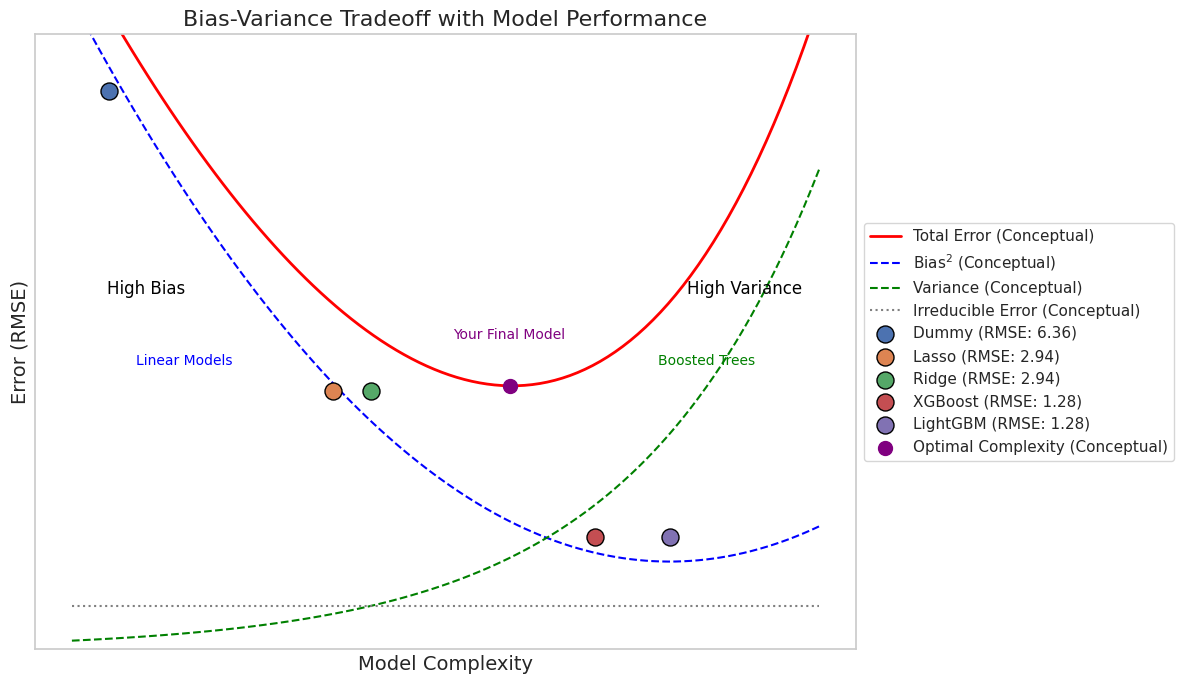

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7)) # Increased figure size for better readability

# model complexity range
x = np.linspace(0, 10, 100)

# Conceptual curves
bias_squared = (x - 8)**2 / 10 + 1  # Example for bias
variance = np.exp(x/2.5) / 10      # Example for variance
noise = np.full_like(x, 0.5)      # Irreducible error
total_error = bias_squared + variance + noise

# Plotting the conceptual curves
plt.plot(x, total_error, label='Total Error (Conceptual)', color='red', linewidth=2)
plt.plot(x, bias_squared, label='Bias$^2$ (Conceptual)', linestyle='--', color='blue')
plt.plot(x, variance, label='Variance (Conceptual)', linestyle='--', color='green')
plt.plot(x, noise, label='Irreducible Error (Conceptual)', linestyle=':', color='gray')

# Arrows and Labels for conceptual diagram
plt.annotate(
    '', xy=(2, 0.5), xytext=(0.5, 3.5), arrowprops=dict(facecolor='black', arrowstyle='->'),
    textcoords='offset points'
)
plt.annotate(
    '', xy=(8, 0.5), xytext=(9.5, 3.5), arrowprops=dict(facecolor='black', arrowstyle='->'),
    textcoords='offset points'
)

# Text annotations for conceptual diagram
plt.text(1, 4, 'High Bias', ha='center', va='bottom', fontsize=12, color='black')
plt.text(9, 4, 'High Variance', ha='center', va='bottom', fontsize=12, color='black')

plt.text(1.5, 3.2, 'Linear Models', ha='center', va='bottom', fontsize=10, color='blue')
plt.text(8.5, 3.2, 'Boosted Trees', ha='center', va='bottom', fontsize=10, color='green')

# --- Plotting actual model results ---

# Conceptual complexities for each model (approximate mapping to the x-axis 0-10)
# These are illustrative positions, not direct measurements of 'complexity'
model_complexity_map = {
    "Dummy": 0.5, # Very low complexity
    "ElasticNet(base)": 3.0,
    "Lasso": 3.5,
    "Ridge": 4.0,
    "ElasticNet(tuned)": 4.5, # Tuned linear model
    "XGBoost": 7.0, # Tree-based, high complexity
    "LightGBM": 8.0, # Tree-based, very high complexity
}

# Get RMSE values from the summary DataFrame (assuming 'summary' is available from previous cells)
model_rmse = summary["RMSE"]

# Plotting the actual model results on the curve
for model_name, complexity in model_complexity_map.items():
    if model_name in model_rmse:
        rmse_val = model_rmse[model_name]
        # Plotting the model's complexity vs its actual RMSE
        plt.scatter(complexity, rmse_val, s=150, zorder=6, label=f'{model_name} (RMSE: {rmse_val:.2f})', edgecolor='black', linewidth=1)

# Re-plotting the 'Optimal Complexity' marker to be on top of other points
min_error_x = x[np.argmin(total_error)]
min_error_y = np.min(total_error)
plt.scatter(min_error_x, min_error_y, color='purple', s=100, zorder=5, label='Optimal Complexity (Conceptual)')
plt.text(min_error_x, min_error_y + 0.5, 'Your Final Model', ha='center', va='bottom', fontsize=10, color='purple')


plt.title('Bias-Variance Tradeoff with Model Performance', fontsize=16)
plt.xlabel('Model Complexity', fontsize=14)
plt.ylabel('Error (RMSE)', fontsize=14)
plt.ylim(0, 7) # Adjusted y-limit to accommodate all RMSE values
plt.xticks([]) # Hide x-axis ticks
plt.yticks([]) # Hide y-axis ticks
plt.grid(False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Adjust legend position to avoid overlap
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results)
summary = results_df.groupby("model")[["MAE", "RMSE", "R2"]].mean().sort_values("RMSE")
display(summary)

,MAE,RMSE,R2
model,,,
XGBoost,0.801802,1.280703,0.959104
LightGBM,0.801975,1.283991,0.958872
Ridge,1.983193,2.935685,0.786331
Lasso,1.982906,2.935825,0.786309
ElasticNet_Tuned,1.983201,2.938638,0.785911
ElasticNet_Base,2.437025,3.735128,0.654558
Dummy,4.688124,6.358232,-0.001406


# Model Evaluation



=== RESULTS ===
               model       mae      rmse        r2
0              Dummy  4.643099  6.142119 -0.000098
1   ElasticNet(base)  1.884522  2.875524  0.780800
2  ElasticNet(tuned)  1.143710  1.851404  0.909133
3              Lasso  1.145031  1.852546  0.909020
4              Ridge  1.145874  1.853141  0.908962
5           LightGBM  0.114745  0.245861  0.998398
6            XGBoost  0.142224  0.263799  0.998155

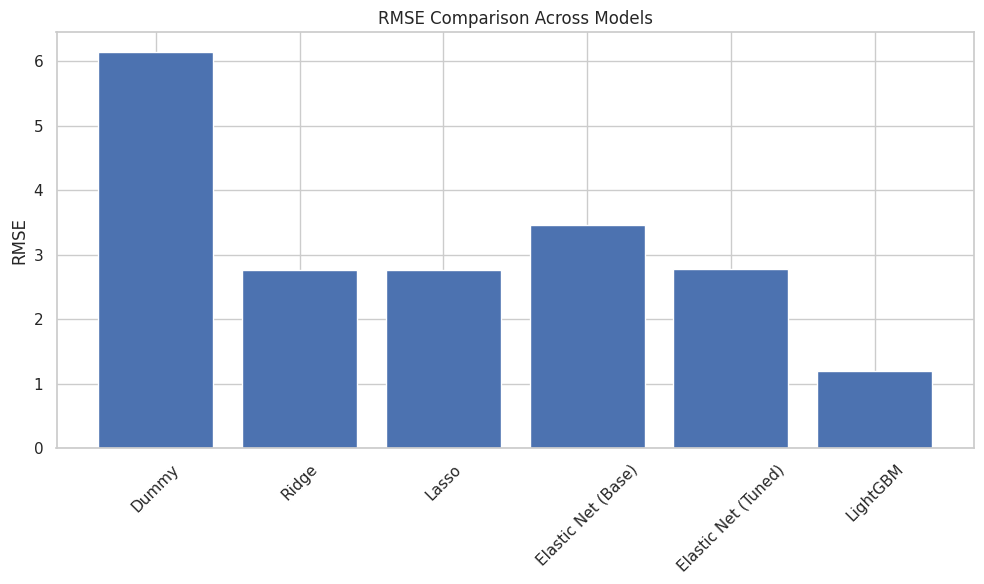

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Dummy",
    "Ridge",
    "Lasso",
    "Elastic Net (Base)",
    "Elastic Net (Tuned)",
    "LightGBM"
]

rmse_values = [
    dummy_metrics["rmse"],
    ridge_metrics['rmse'],
    lasso_metrics['rmse'],
    enet_base_metrics['rmse'],
    enet_tuned_metrics['rmse'],
    test_rmse
]

plt.figure()
plt.bar(models, rmse_values)
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Models")
plt.tight_layout()
plt.show()

Why choose elastic net over ridge and lasso if its a very similar rmse? Its because it balances the lasso's instability with correlated features and ridge's inability to remove irrelevant features. So even if the RMSE is similar, Elastic Net tends to be more stable across resamples.

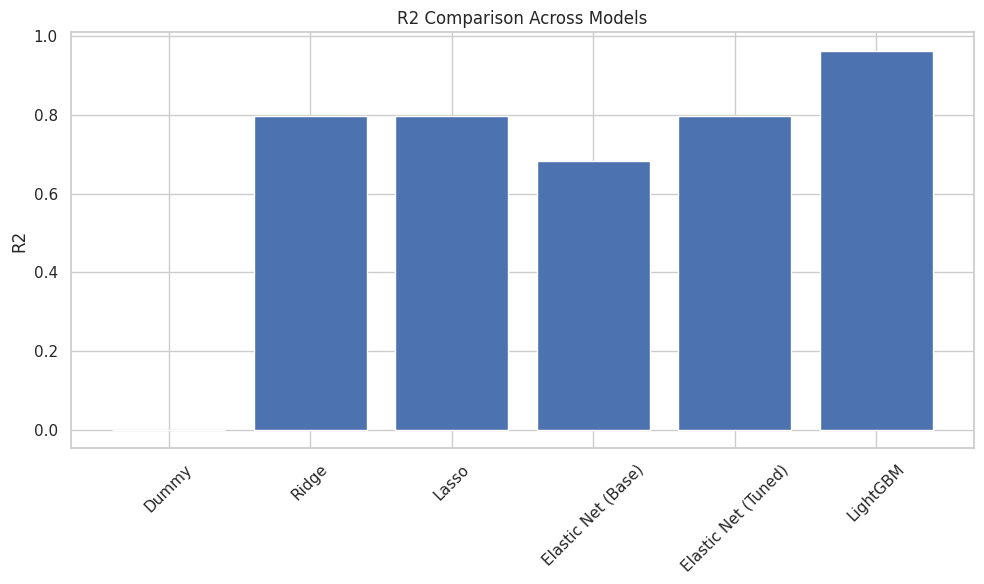

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Dummy",
    "Ridge",
    "Lasso",
    "Elastic Net (Base)",
    "Elastic Net (Tuned)",
    "LightGBM"
]

rmse_values = [
    dummy_metrics['r2'],
    ridge_metrics['r2'],
    lasso_metrics['r2'],
    enet_base_metrics['r2'],
    enet_tuned_metrics['r2'],
    test_r2
]

plt.figure()
plt.bar(models, rmse_values)
plt.xticks(rotation=45)
plt.ylabel("R2")
plt.title("R2 Comparison Across Models")
plt.tight_layout()
plt.show()

Although Elastic Net tuning significantly improved linear model performance, LightGBM achieved substantially higher R², indicating strong nonlinear relationships and interactions that linear models fail to capture.

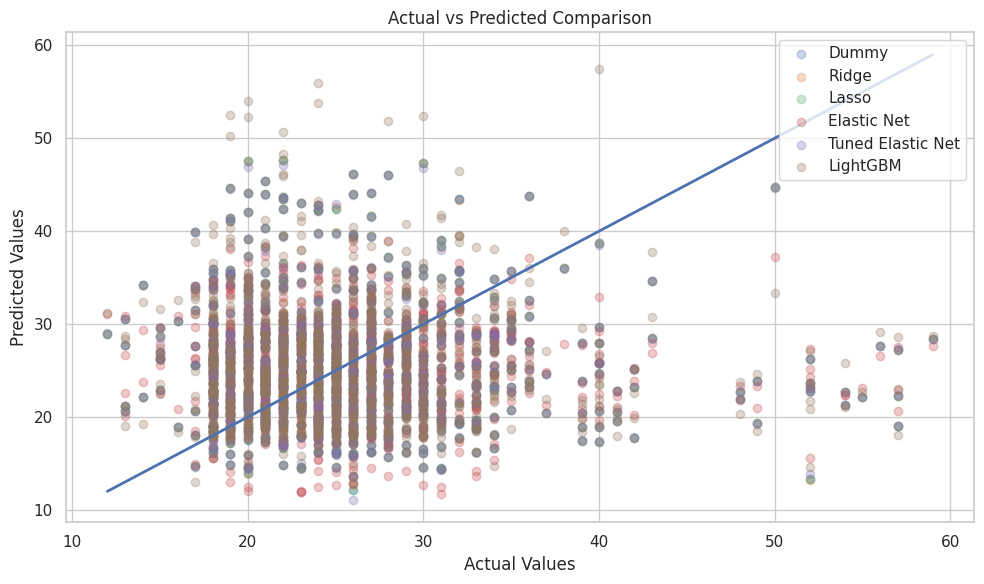

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# Perfect prediction line
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

# Scatter predictions
plt.scatter(y_test, lasso_pred, alpha=0.3, label="Dummy")
plt.scatter(y_test, ridge_pred, alpha=0.3, label="Ridge")
plt.scatter(y_test, lasso_pred, alpha=0.3, label="Lasso")
plt.scatter(y_test, enet_base_pred, alpha=0.3, label="Elastic Net")
plt.scatter(y_test, enet_tuned_pred, alpha=0.3, label="Tuned Elastic Net")
plt.scatter(y_test, y_pred_lgb, alpha=0.3, label="LightGBM")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.tight_layout()
plt.show()

Hyperparameter tuning significantly improved Elastic Net performance compared to its default configuration, demonstrating the importance of regularization strength and L1/L2 balance.

The optimal l1_ratio of 0.5 indicates that a balanced combination of sparsity and shrinkage provides the best bias to variance tradeoff for this dataset.

The substantial performance improvement achieved by LightGBM indicates the presence of nonlinear relationships and feature interactions not captured by linear models.